# Data Preprocessing

We noticed that the composition of the competition changed slightly across years (e.g., in some years they did free variation, some years contemporary variation, some years both), but in all years they did at least one classical variation, so we would study how gestures changed in the classical variation.


Here is our data preprocessing pipeline:

Firstly, we found some errors in the metadata, and we have fixed them:

- `edition35/edition35_sequence_32.mp4` (2007): The music should be *La Bayadère -- Gamzatti variation*.
- `edition23/edition23_sequence_23.mp4` (1995): This is *free* instead of classical.
- `edition29/edition29_sequence_10.mp4` (2001): This is *classical* instead of free.
- `edition22/edition22_sequence_28.mp4` (1994): This is *free* instead of classical.
- `edition23/edition23_sequence_19.mp4` (1995): This is *free* instead of classical.
- `edition25/edition25_sequence_26.mp4` (1997): This is *free* instead of classical.

There are some lines with the label "results" that simply repeat mentioning dancers and their results. These unnecessary lines are deleted.

In 2006 and 2007, finalists did two classical variations, and we manually selected the one with costume by looking at the competition video.

In years like 1976, a few dancers only had videos for free variation, but no videos for classical variation. We have to rule them out from our movement evolution analysis, but they will be kept in other analyses.

There are results in 2022 and 2023, but no labels in the "has_award" column were added. So we added the corresponding label.

There are no results for 2025, and completely no information for 2026. These results (as well as 2026 videos) have been manually added by us.

There are only photos for the years 1973, 1974, 1975, 1977, 1980, 1989, 2004, 2015. 2004 and 2015 videos might be available online. Other years can't be used to study our movement evolution analysis, but they will be kept in other analyses.

After that, we keep two tables:

- The first table includes all dancers with a contemporary variation performance (we keep the line with the contemporary variation performance), and it is used for movement evolution analysis.
- The second table includes all dancers in the competition (we keep the line with the contemporary variation performance if available, otherwise we keep a random other line), and it is used for all other analyses.

The final step is to label genders for dancers. We input all names into 5 local GPTs and let them label gender independently. Afterwards we have 4 types of results:

- male (if 5 labels are all male)
- female (if 5 labels are all female)
- mainly male (if there are 3/4 male labels)
- mainly female (if there are 3/4 female labels)

Then we checked and corrected these labels manually by looking at dancers' IDs, videos, photos, and searching through the Internet. It turned out that:

- 3% of male labels are wrong
- 2% of female labels are wrong
- 30% of likely male labels are wrong
- 23% of likely female labels are wrong

We also found 1 non-binary dancer.

For very few (less than 3%) dancers, we don't have any information about them and we have to keep the machine label (likely male and likely female are turned to male and female respectively), but these minority cases do not affect the statistical pattern of the data.

Most of the preprocessing steps described above are done manually, making it difficult to provide complete code. This may be a characteristic of digital humanities data, where data is more difficult to preprocess entirely through code.

# Data Analysis

In [1]:
import pandas as pd
df = pd.read_csv('Other_Analysis.csv', encoding='utf-8', encoding_errors='ignore')

We have 863 participants for analysis.

In [2]:
df.shape

(863, 24)

## Part 1: Country

In this part, we attempt to explore which countries have the most winners in this event, and whether this trend changes over time.

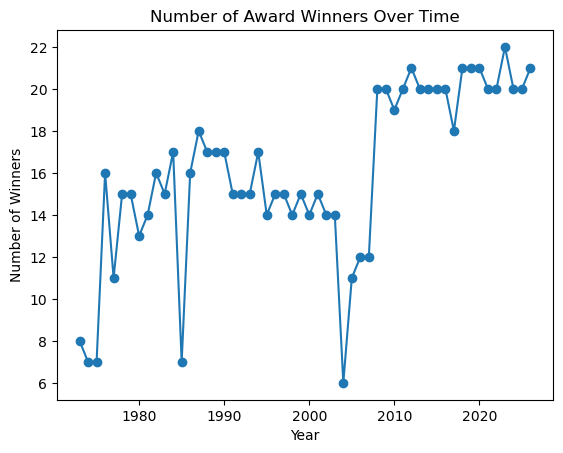

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

year_min = df["year"].min()
year_max = df["year"].max()
all_years = pd.Series(range(year_min, year_max + 1), name="year")

winners_per_year = df.groupby("year").size()

winners_per_year = winners_per_year.reindex(all_years, fill_value=0)

plt.figure()
winners_per_year.plot(marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Winners")
plt.title("Number of Award Winners Over Time")
plt.show()

<Figure size 640x480 with 0 Axes>

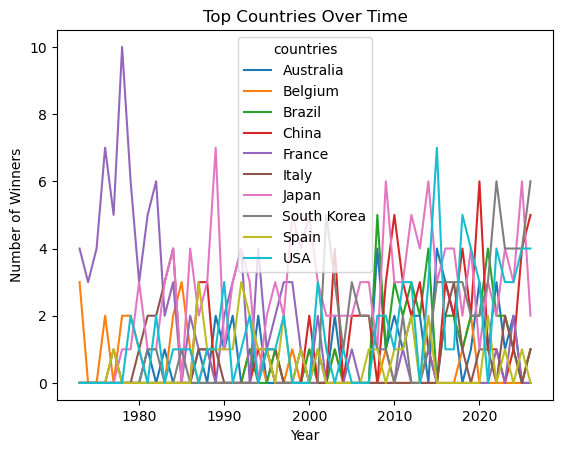

In [4]:
top_countries = df["countries"].value_counts().head(10).index

df_top = df[df["countries"].isin(top_countries)]

country_year = df_top.groupby(["year", "countries"]).size().unstack(fill_value=0)

plt.figure()
country_year.plot()
plt.xlabel("Year")
plt.ylabel("Number of Winners")
plt.title("Top Countries Over Time")
plt.show()

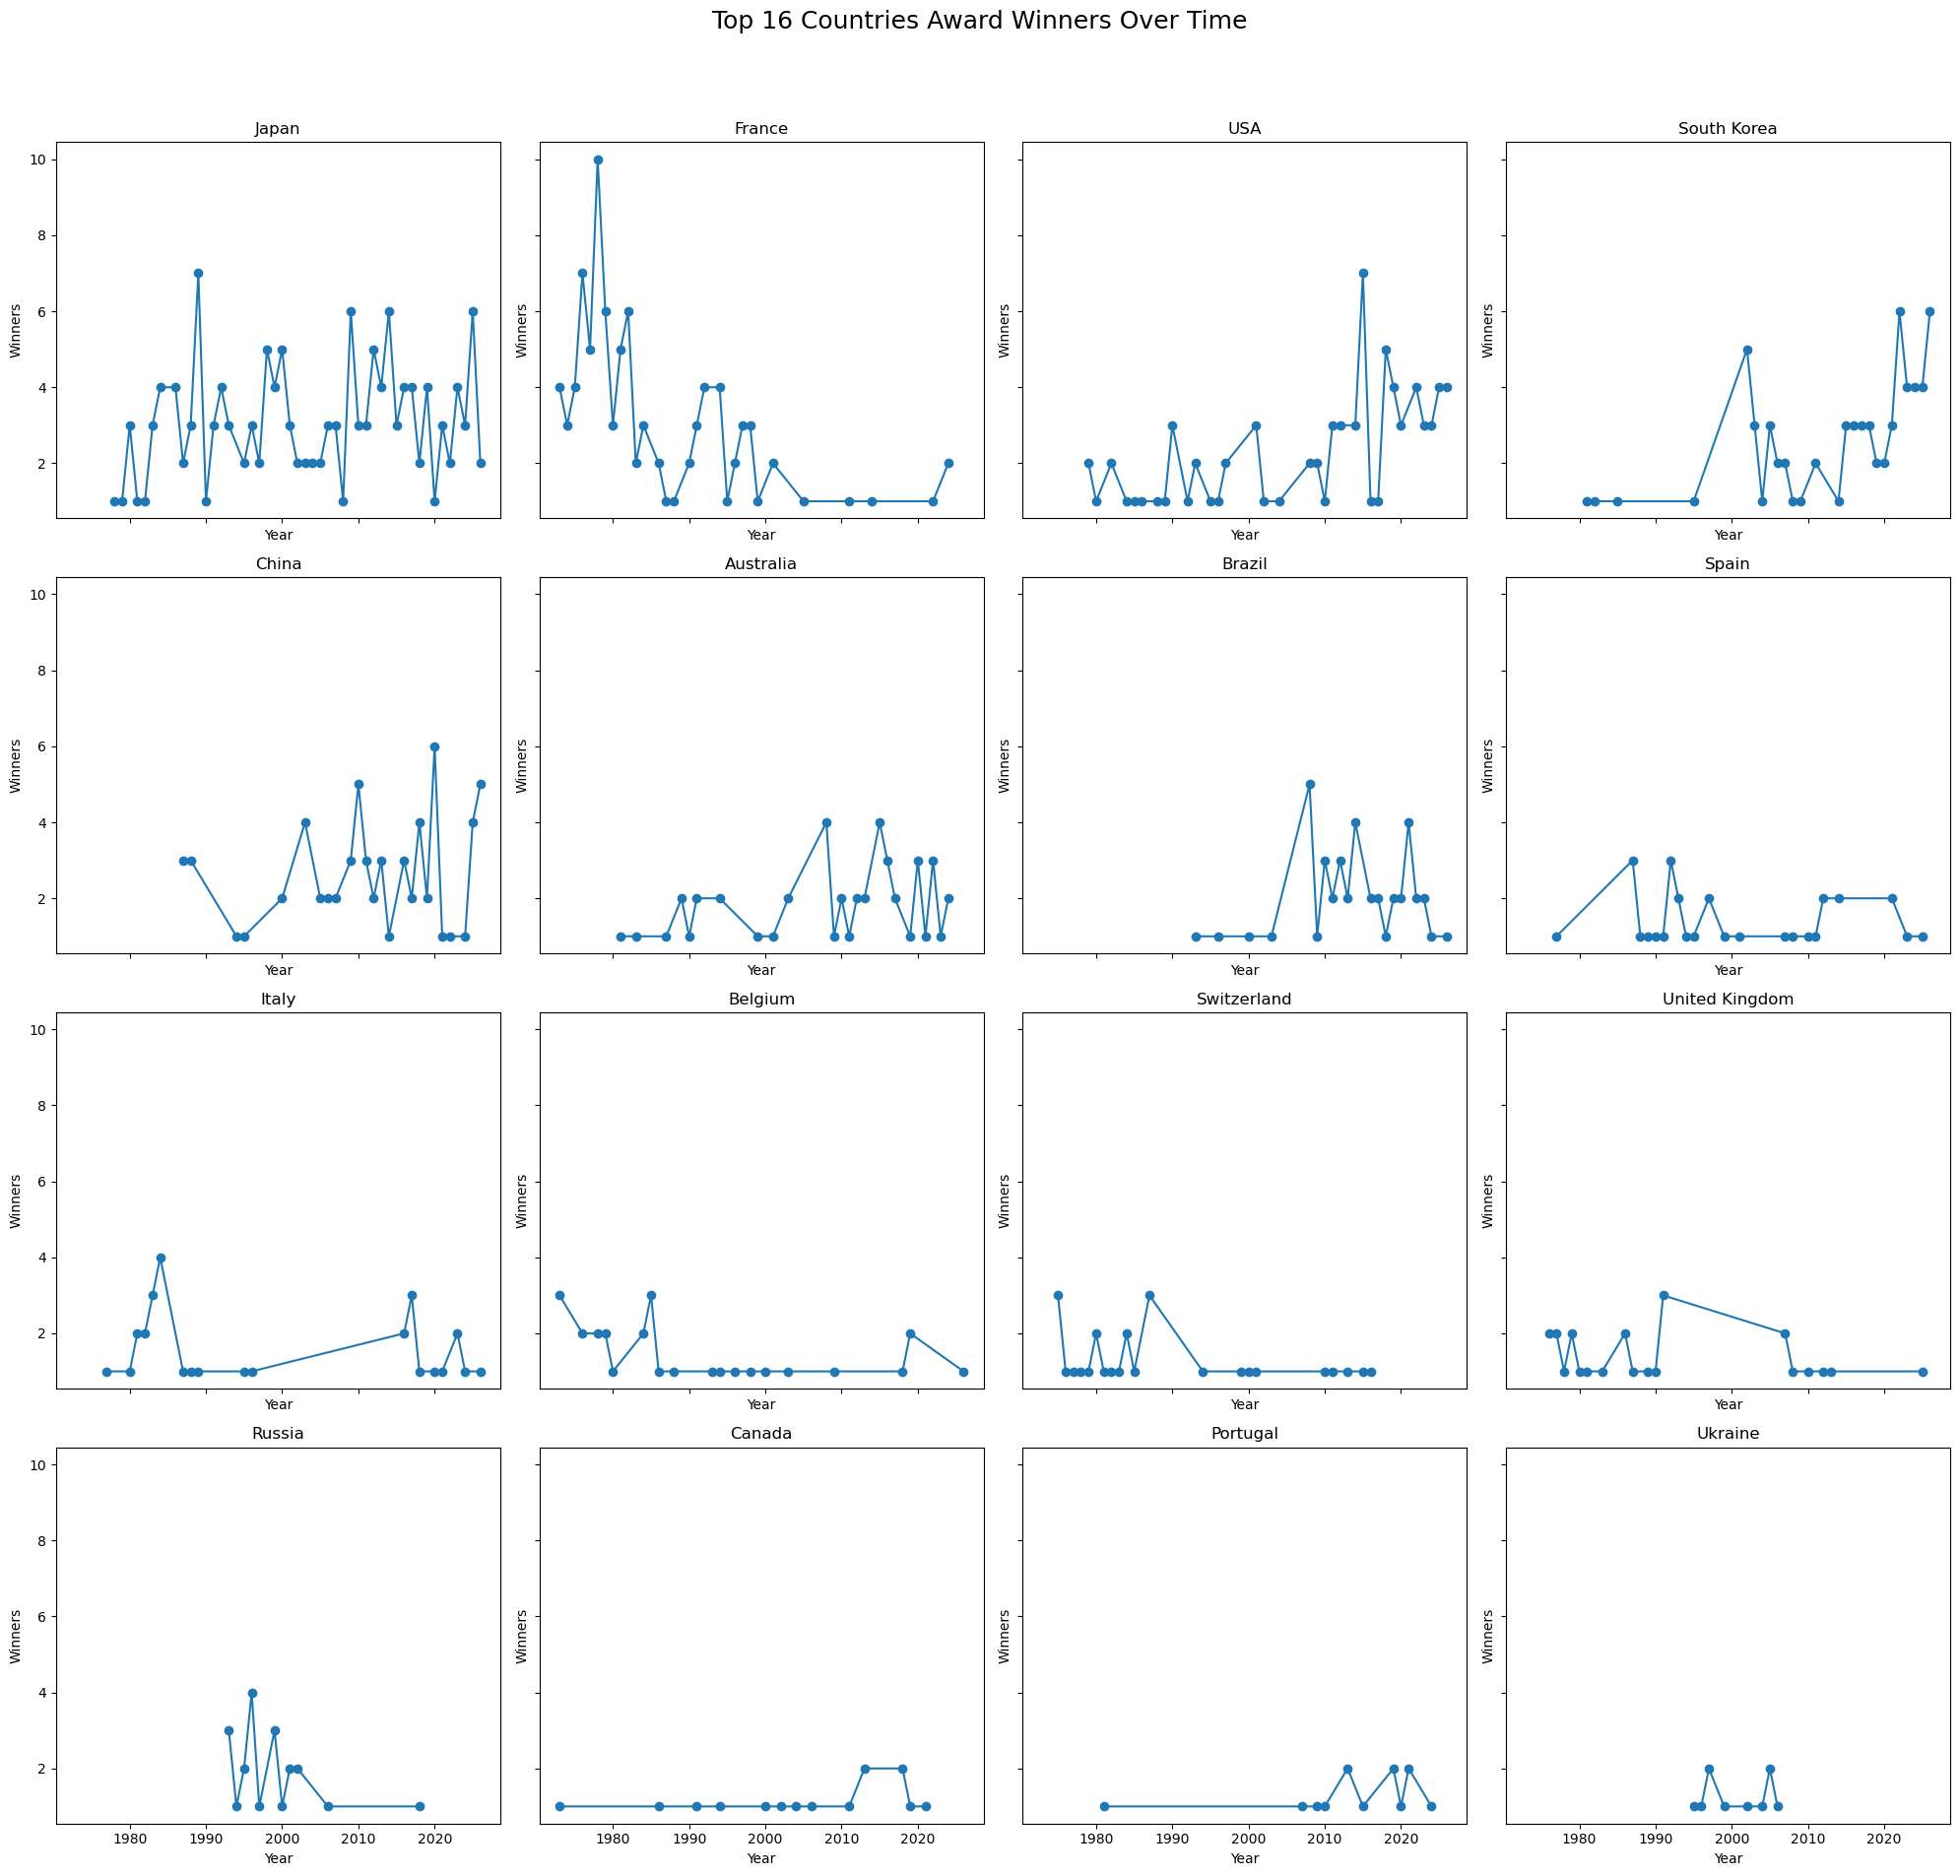

In [5]:
# Top 16 countries
top_16_countries = df["countries"].value_counts().head(16).index

# plot 4*4
fig, axes = plt.subplots(4, 4, figsize=(20, 20), sharex=True, sharey=True)
axes = axes.flatten() 

for i, country in enumerate(top_16_countries):
    data = df[df["countries"] == country]
    winners_per_year = data.groupby("year").size()
    
    axes[i].plot(winners_per_year.index, winners_per_year.values, marker='o')
    axes[i].set_title(country)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Winners")

plt.suptitle("Top 16 Countries Award Winners Over Time", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

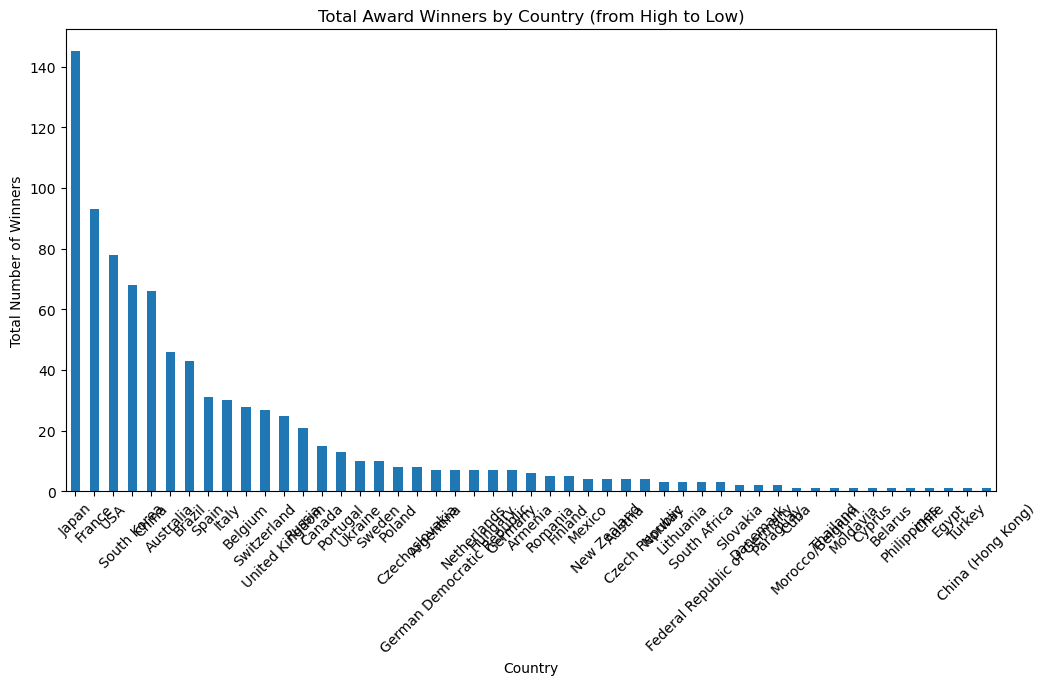

In [6]:
country_counts = df["countries"].value_counts()

plt.figure(figsize=(12, 6))
country_counts.plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Total Number of Winners")
plt.title("Total Award Winners by Country (from High to Low)")
plt.xticks(rotation=45)
plt.show()

We have also analyzed by decades.

=== 1970s ===
['(France, 39)', '(Belgium, 9)', '(Switzerland, 7)']
=== 1980s ===
['(Japan, 28)', '(France, 23)', '(Italy, 15)']
=== 1990s ===
['(Japan, 27)', '(France, 23)', '(Russia, 14)']
=== 2000s ===
['(Japan, 29)', '(South Korea, 18)', '(China, 15)']
=== 2010s ===
['(Japan, 38)', '(USA, 28)', '(China, 25)']
=== 2020s ===
['(South Korea, 29)', '(Japan, 21)', '(USA, 21)']


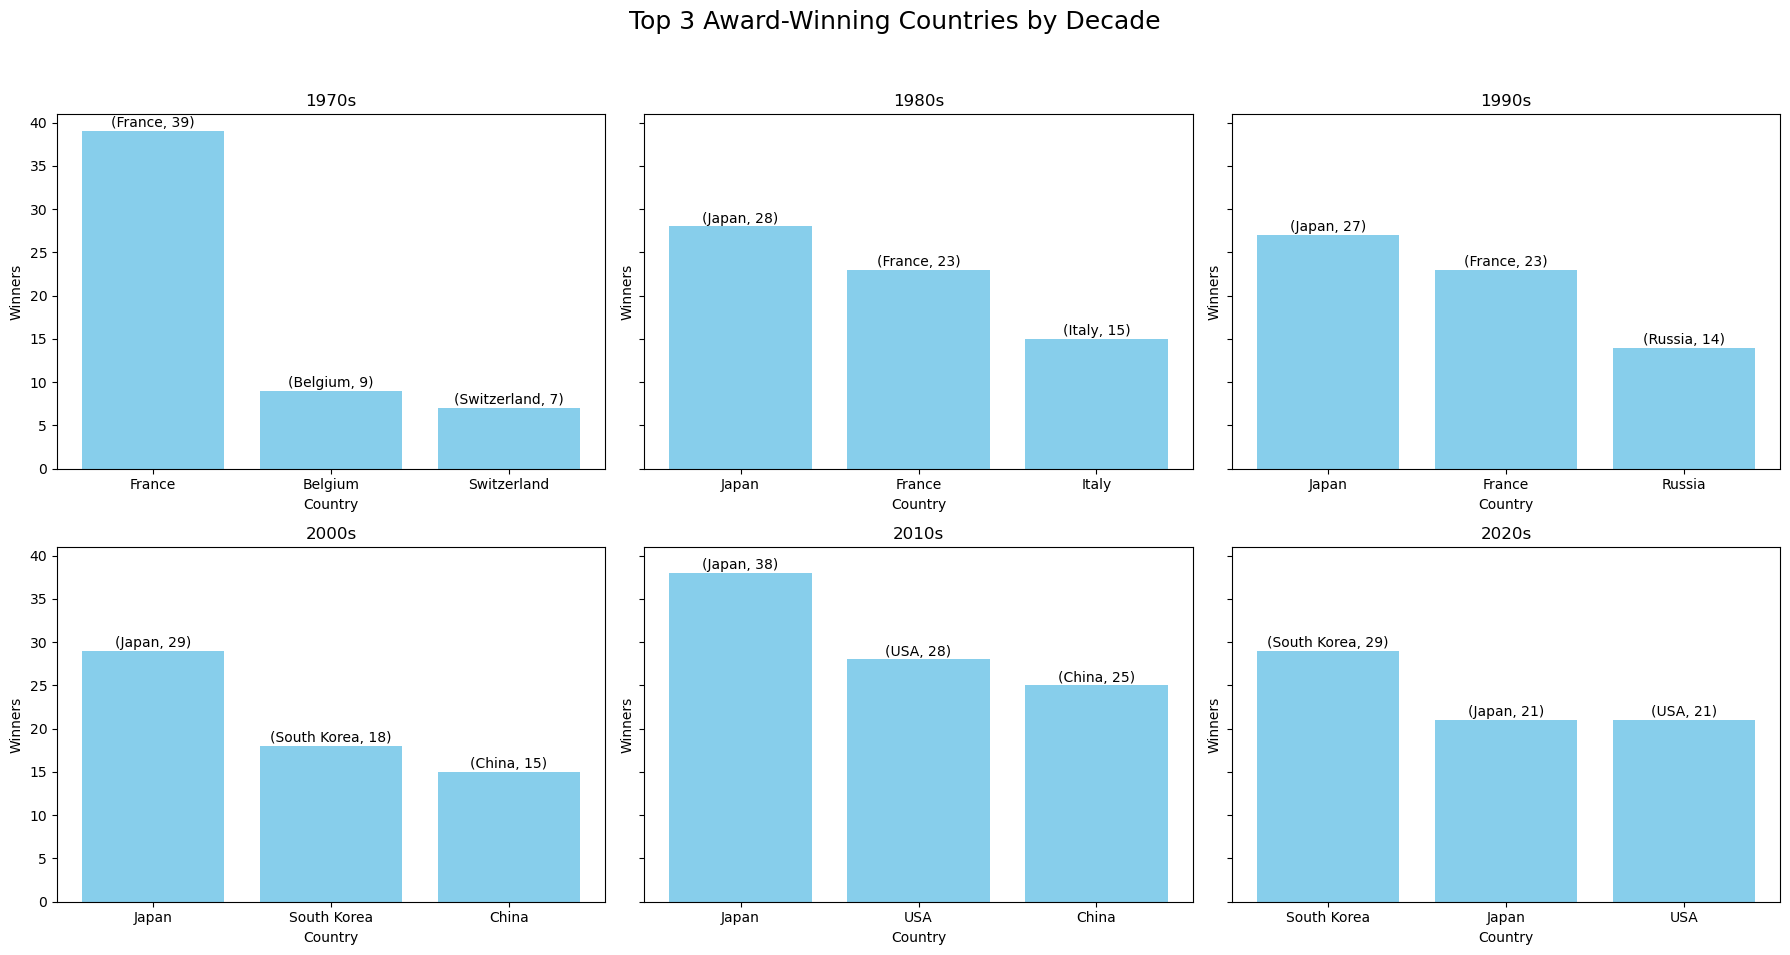

In [7]:
df = df.copy()
df['decade'] = (df['year'] // 10) * 10

decade_country_counts = df.groupby(['decade', 'countries']).size().reset_index(name='count')

top3_per_decade = (
    decade_country_counts
    .sort_values(['decade', 'count'], ascending=[True, False])
    .groupby('decade', group_keys=False)
    .head(3)
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, decade in enumerate(sorted(top3_per_decade['decade'].unique())):
    df_decade = top3_per_decade[top3_per_decade['decade'] == decade]
    
    print(f"=== {decade}s ===")
    print([f"({row['countries']}, {row['count']})" for _, row in df_decade.iterrows()])
    
    bars = axes[i].bar(df_decade['countries'], df_decade['count'], color='skyblue')
    axes[i].set_title(f"{decade}s")
    axes[i].set_xlabel("Country")
    axes[i].set_ylabel("Winners")
    for bar, country, count in zip(bars, df_decade['countries'], df_decade['count']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"({country}, {count})", 
                     ha='center', va='bottom', fontsize=10)

plt.suptitle("Top 3 Award-Winning Countries by Decade", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Japan, France, and the United States have the most cumulative winners. France dominated the early stages of the competition, but Japan subsequently took a commanding lead. After the 20th century, the nationalities of the winners became more diverse, with countries like the United States, South Korea, and China producing a significant number of winners, and the gap between countries narrowing.

## Part 2: Continent

Next, we will attempt to analyze the winners by continent.

In [8]:
unique_countries = df['countries'].unique()
print(sorted(df['countries'].dropna().unique()))

['Argentina', 'Armenia', 'Australia', 'Austria', 'Belarus', 'Belgium', 'Brazil', 'Canada', 'Chile', 'China', 'China (Hong Kong)', 'Cuba', 'Cyprus', 'Czech Republic', 'Czechoslovakia', 'Danemark', 'Egypt', 'Federal Republic of Germany', 'Finland', 'France', 'German Democratic Republic', 'Germany', 'Hungary', 'Italy', 'Japan', 'Lithuania', 'Mexico', 'Moldavia', 'Morocco/Belgium', 'Netherlands', 'New Zealand', 'Norway', 'Paraguay', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Slovakia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'Turkey', 'USA', 'Ukraine', 'United Kingdom']


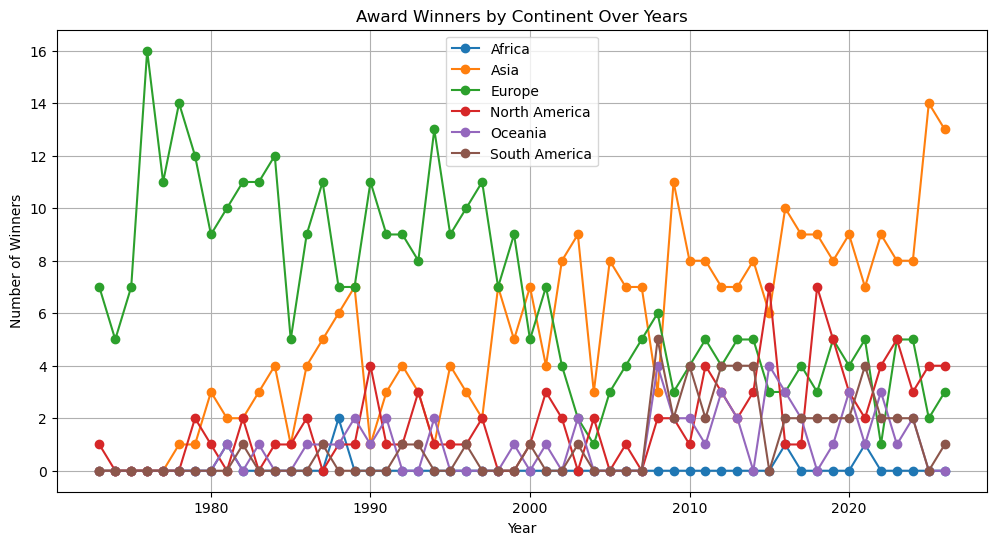

In [9]:
country_to_continent = {
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Belarus': 'Europe',
    'Belgium': 'Europe',
    'Brazil': 'South America',
    'Canada': 'North America',
    'Chile': 'South America',
    'China': 'Asia',
    'Cuba': 'North America',
    'Cyprus': 'Europe',
    'Czech Republic': 'Europe',
    'Czechoslovakia': 'Europe',
    'Danemark': 'Europe',
    'Egypt': 'Africa',
    'Federal Republic of Germany': 'Europe',
    'Finland': 'Europe',
    'France': 'Europe',
    'German Democratic Republic': 'Europe',
    'Germany': 'Europe',
    'Hungary': 'Europe',
    'Italy': 'Europe',
    'Japan': 'Asia',
    'Lithuania': 'Europe',
    'Mexico': 'North America',
    'Moldavia': 'Europe',
    'Morocco/Belgium': 'Africa',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Norway': 'Europe',
    'Paraguay': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Romania': 'Europe',
    'Russia': 'Europe',
    'Slovakia': 'Europe',
    'South Africa': 'Africa',
    'South Korea': 'Asia',
    'Spain': 'Europe',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Thailand': 'Asia',
    'USA': 'North America',
    'Ukraine': 'Europe',
    'United Kingdom': 'Europe'
}

df = df.copy()
df['continent'] = df['countries'].map(country_to_continent)

all_years = range(df['year'].min(), df['year'].max()+1)

continent_year = df.groupby(['year','continent']).size().unstack(fill_value=0)

continent_year = continent_year.reindex(all_years, fill_value=0)

plt.figure(figsize=(12,6))
for continent in continent_year.columns:
    plt.plot(continent_year.index, continent_year[continent], marker='o', label=continent)

plt.xlabel("Year")
plt.ylabel("Number of Winners")
plt.title("Award Winners by Continent Over Years")
plt.legend()
plt.grid(True)
plt.show()

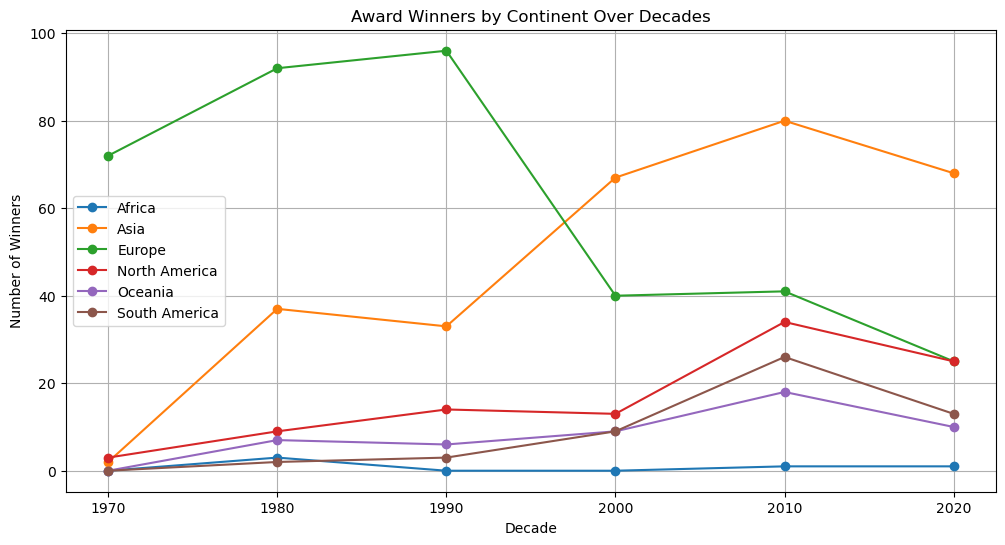

In [10]:
df = df.copy()
df['continent'] = df['countries'].map(country_to_continent)
df['decade'] = (df['year'] // 10) * 10

continent_decade = df.groupby(['decade','continent']).size().unstack(fill_value=0)

all_decades = range(df['decade'].min(), df['decade'].max()+10, 10)
continent_decade = continent_decade.reindex(all_decades, fill_value=0)

plt.figure(figsize=(12,6))
for continent in continent_decade.columns:
    plt.plot(continent_decade.index, continent_decade[continent], marker='o', label=continent)

plt.xlabel("Decade")
plt.ylabel("Number of Winners")
plt.title("Award Winners by Continent Over Decades")
plt.legend()
plt.grid(True)
plt.show()

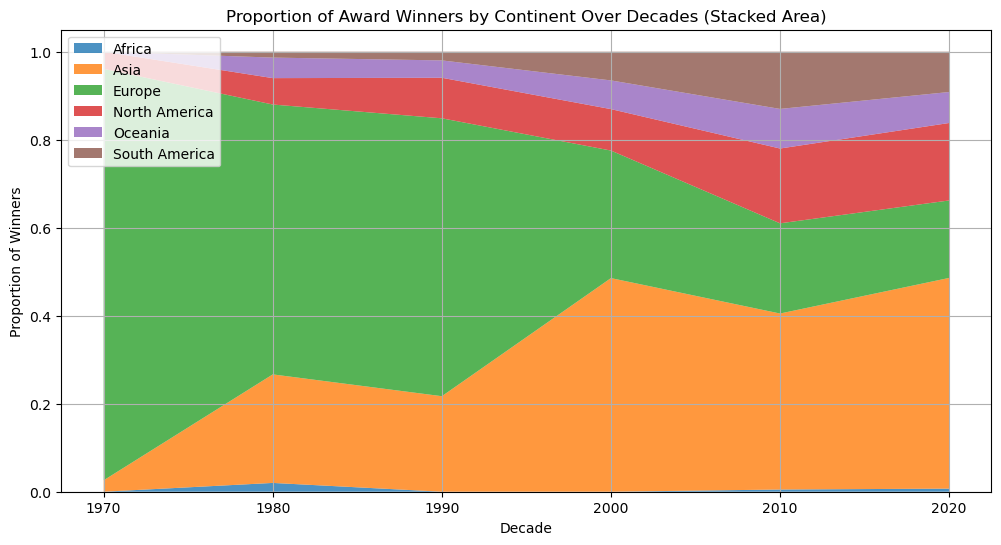

In [11]:
df['decade'] = (df['year'] // 10) * 10
continent_decade = df.groupby(['decade','continent']).size().unstack(fill_value=0)

all_decades = range(df['decade'].min(), df['decade'].max()+10, 10)
continent_decade = continent_decade.reindex(all_decades, fill_value=0)

continent_decade_prop = continent_decade.div(continent_decade.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
plt.stackplot(
    continent_decade_prop.index,
    [continent_decade_prop[col] for col in continent_decade_prop.columns],  
    labels=continent_decade_prop.columns,
    alpha=0.8
)

plt.xlabel("Decade")
plt.ylabel("Proportion of Winners")
plt.title("Proportion of Award Winners by Continent Over Decades (Stacked Area)")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

It is clear that Europe dominated the competition in its early stages, but the proportion of Asian winners increased significantly after 1990, surpassing Europe and consistently ranking as the continent with the most winners. The proportion of winners from North America, South America, and Oceania also steadily increased in the 21st century. Overall, the globalization of ballet competitions has been well demonstrated and confirmed.

## Part 3: Gender

Finally, we attempted to study the changing trends in the gender ratio of the award winners.

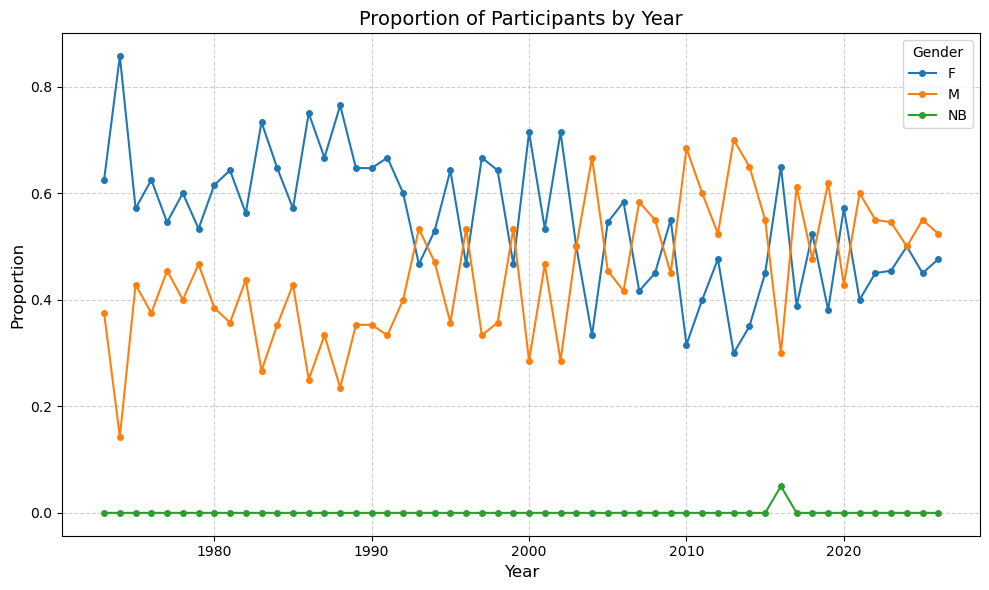

In [12]:
yearly_counts = df.groupby(['year', 'real_gender']).size().unstack(fill_value=0)
yearly_props = yearly_counts.div(yearly_counts.sum(axis=1), axis=0)

plt.figure(figsize=(10, 6))
for gender in yearly_props.columns:
    plt.plot(yearly_props.index, yearly_props[gender], label=gender, marker='o', markersize=4)

plt.title('Proportion of Participants by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

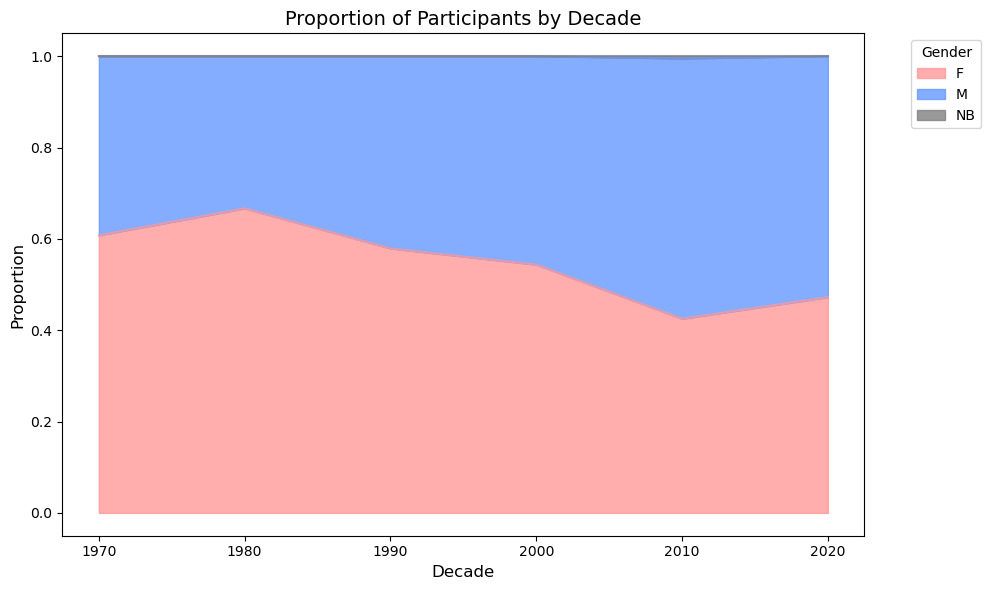

In [13]:
df['decade'] = (df['year'] // 10) * 10
decade_counts = df.groupby(['decade', 'real_gender']).size().unstack(fill_value=0)
decade_props = decade_counts.div(decade_counts.sum(axis=1), axis=0)

color_mapping = {'M': '#6699ff', 'F': '#ff9999'}
colors = [color_mapping.get(col, 'gray') for col in decade_props.columns]

ax = decade_props.plot(kind='area', stacked=True, alpha=0.8, figsize=(10, 6), color=colors)
plt.title('Proportion of Participants by Decade', fontsize=14)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In the early stages of the competition, there were far more female winners than male winners (we do not have data on early participants, but we can infer that there were more female participants in the early stages as well), but the proportion of male winners has increased year by year, and is now approaching a 50/50 balance between men and women. Overall, the gender structure of the competition is gradually becoming more equal.